# Day 11 — matplotlib可视化实战
## 今日目标：把股票数据画成专业图表

四种核心图表：
- **K线图**（蜡烛图）— 股价走势的灵魂，mplfinance一笔画
- **均线叠加** — 收盘价+MA5+MA20，看趋势方向
- **成交量柱状图** — 量价配合，红涨绿跌
- **收益率直方图** — 风险分布一览无余

> ⚠️ 今天东方财富接口限流，数据已提前存到 `data/` 目录的 CSV 文件里，直接从本地读。

findfont: Failed to find font weight medium, now using 400.


中文字体已加载: /System/Library/AssetsV2/com_apple_MobileAsset_Font8/86ba2c91f017a3749571a82f2c6d890ac7ffb2fb.asset/AssetData/PingFang.ttc


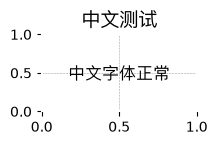

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib
import mplfinance as mpf
import os, glob

# 清除 matplotlib 字体缓存
cache_dir = matplotlib.get_cachedir()
for f in glob.glob(os.path.join(cache_dir, 'fontlist*.json')):
    try:
        os.remove(f)
    except:
        pass

fm._load_fontmanager(try_read_cache=False)

# 找到 PingFang SC 的字体文件路径（system .ttc 文件）
_pf_path = None
for _f in fm.fontManager.ttflist:
    if _f.name == 'PingFang SC' and _f.weight == 400:
        _pf_path = _f.fname
        break

if _pf_path:
    # 用文件路径创建 FontProperties，绕过 matplotlib 字体查找（根治 Jupyter inline 显示"字字字"）
    zh = fm.FontProperties(fname=_pf_path, size=12)
    zh_title = fm.FontProperties(fname=_pf_path, size=14)
    zh_small = fm.FontProperties(fname=_pf_path, size=9)
    print(f'中文字体已加载: {_pf_path}')
else:
    zh = zh_title = zh_small = None
    print('WARNING: 未找到中文字体文件！')

plt.rcParams['axes.unicode_minus'] = False

# 快速验证
fig, ax = plt.subplots(figsize=(2, 1))
ax.set_title('中文测试', fontproperties=zh_title)
ax.text(0.5, 0.5, '中文字体正常', ha='center', va='center', fontproperties=zh)
plt.show()

## 1. 从本地CSV读数据（避免API限流）

In [16]:
# 读茅台CSV，设日期为索引
df = pd.read_csv('../data/茅台.csv')
df['日期'] = pd.to_datetime(df['日期'])
df.set_index('日期', inplace=True)

# 算均线和日收益率
df['MA5'] = df['收盘'].rolling(5).mean()
df['MA20'] = df['收盘'].rolling(20).mean()
df['日收益率'] = df['收盘'].pct_change()

print(f'数据: {df.shape[0]}天, {df.index[0].date()} ~ {df.index[-1].date()}')
df[['开盘','收盘','最高','最低','成交量','MA5','MA20']].tail()

数据: 250天, 2025-07-01 ~ 2026-07-10


,开盘,收盘,最高,最低,成交量,MA5,MA20
日期,,,,,,,
2026-07-06,1186.00,1206.91,1215.00,1180.00,40970,1196.572,1210.6685
2026-07-07,1200.00,1188.80,1202.00,1188.11,27365,1197.234,1208.3605
2026-07-08,1188.77,1199.30,1200.98,1177.00,25776,1198.492,1206.9265
2026-07-09,1191.00,1182.19,1191.99,1178.00,34096,1194.330,1203.6430
2026-07-10,1182.20,1204.98,1204.98,1170.28,52213,1196.436,1201.3430


## 2. 🔥 K线图（蜡烛图）

一根蜡烛 = 一天的战斗记录，四个关键价格：

```
茅台某天：
  开盘 1357元 ──→ 早上9:30第一笔成交价
  收盘 1370元 ──→ 下午3:00最后一笔成交价  
  最高 1380元 ──→ 今天冲到过的最高点
  最低 1355元 ──→ 今天砸到过的最低点
```

**怎么画成一根蜡烛：**

```
        最高 1380 ─── 上影线（细线）
        
  收盘 > 开盘 → 涨了！
        收盘 1370 ─┐
        ┃████████┃ ← 实体（粗柱子），红色=涨
        开盘 1357 ─┘
        
        最低 1355 ─── 下影线（细线）
```

**三种情况：**

| 情况 | 颜色 | 含义 |
|------|------|------|
| 收盘 > 开盘 | 🔴 红柱 | 今天涨了，买方赢 |
| 收盘 < 开盘 | 🟢 绿柱 | 今天跌了，卖方赢 |
| 收盘 ≈ 开盘 | 十字星 | 多空打平，方向不明 |

**影线长短告诉你什么：**
- 上影线很长 → 盘中冲高但被砸回来（上方压力大）
- 下影线很长 → 盘中暴跌但被拉回来（下方有支撑）
- 没有影线 → 光头光脚，走势干脆利落

> 💡 **一句话：实体看方向（涨还是跌），影线看激烈程度（有没有人反抗）。**

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


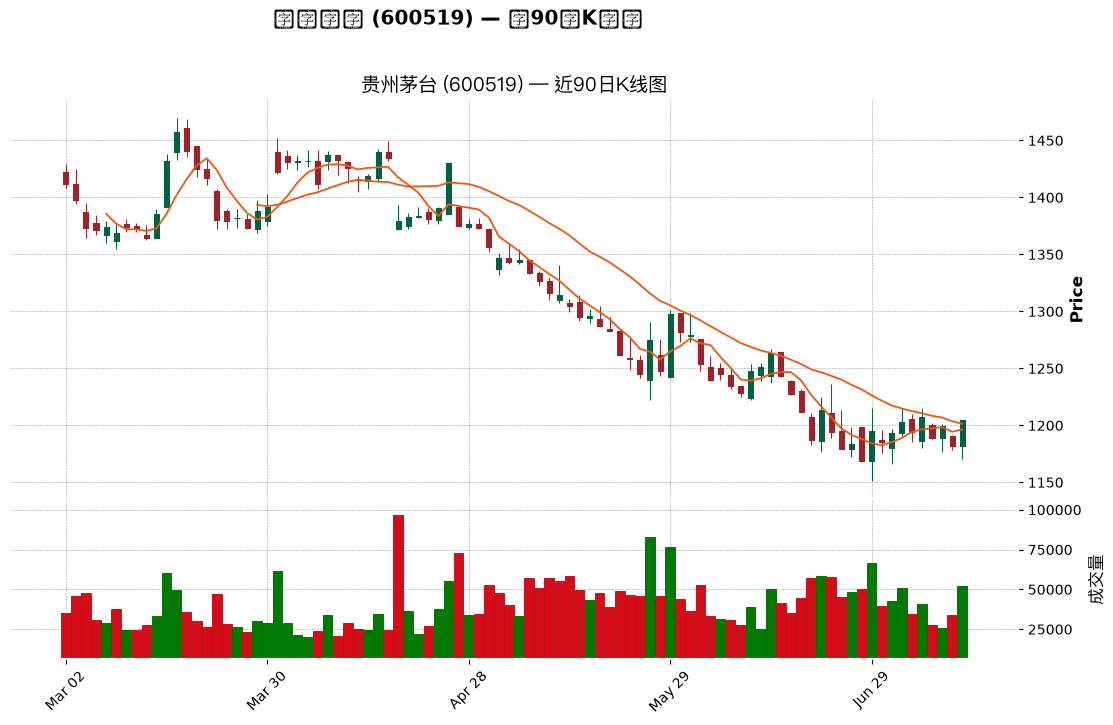

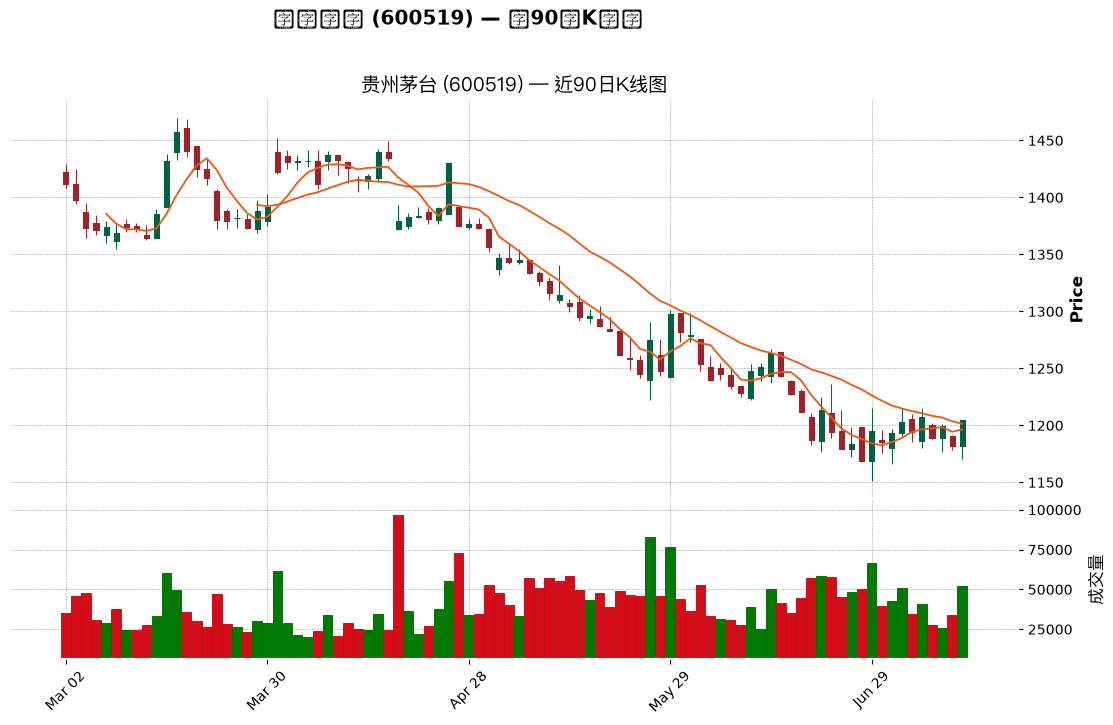

In [17]:
# 列名改成mplfinance要的英文
df_mpf = df[['开盘','收盘','最高','最低','成交量']].copy()
df_mpf.columns = ['Open', 'Close', 'High', 'Low', 'Volume']

# returnfig=True 拿回 fig 和 axes，可以手动改标题字体
fig, axlist = mpf.plot(df_mpf[-90:],
                       type='candle',
                       volume=True,
                       mav=(5, 20),
                       title='贵州茅台 (600519) — 近90日K线图',
                       style='charles',
                       figsize=(14, 8),
                       returnfig=True)

# 修改主图标题和成交量标签的字体
axlist[0].set_title('贵州茅台 (600519) — 近90日K线图', fontproperties=zh_title)
if len(axlist) >= 3:
    axlist[2].set_ylabel('成交量', fontproperties=zh)

# returnfig=True 不自动显示，需要手动 render
fig  # Jupyter 里最后一行写 fig 就会显示

## 3. 收盘价+均线叠加

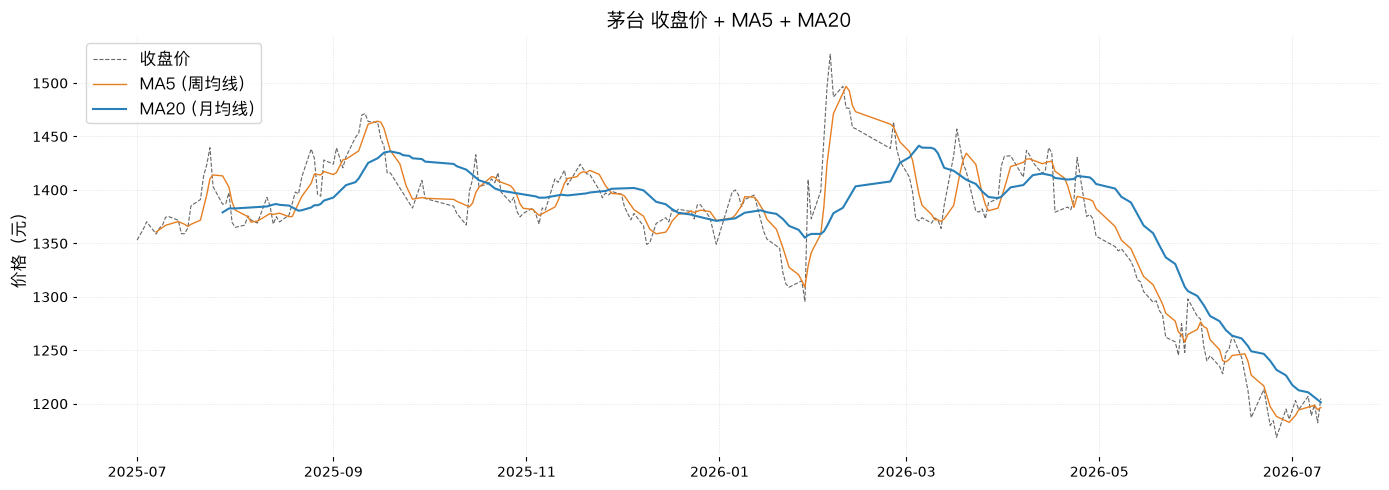

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))

# 收盘价用黑色虚线，不会被网格吃掉
ax.plot(df.index, df['收盘'], linewidth=0.8, alpha=0.6, label='收盘价', color='black', linestyle='--')
ax.plot(df.index, df['MA5'], linewidth=1, label='MA5 (周均线)', color='#e67e22')
ax.plot(df.index, df['MA20'], linewidth=1.5, label='MA20 (月均线)', color='#2980b9')

ax.set_title('茅台 收盘价 + MA5 + MA20', fontproperties=zh_title)
ax.set_ylabel('价格（元）', fontproperties=zh)
ax.legend(loc='upper left', prop=zh)  # legend 用 prop 不是 fontproperties
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/Day11_均线叠加.png', dpi=150)
plt.show()

**均线怎么看：**
- MA5在MA20上面 → 短期强，上涨趋势 🟢
- MA5跌破MA20 → 可能转跌（死叉） 🔴
- MA5上穿MA20 → 可能转涨（金叉） 🟢

## 4. 成交量柱状图

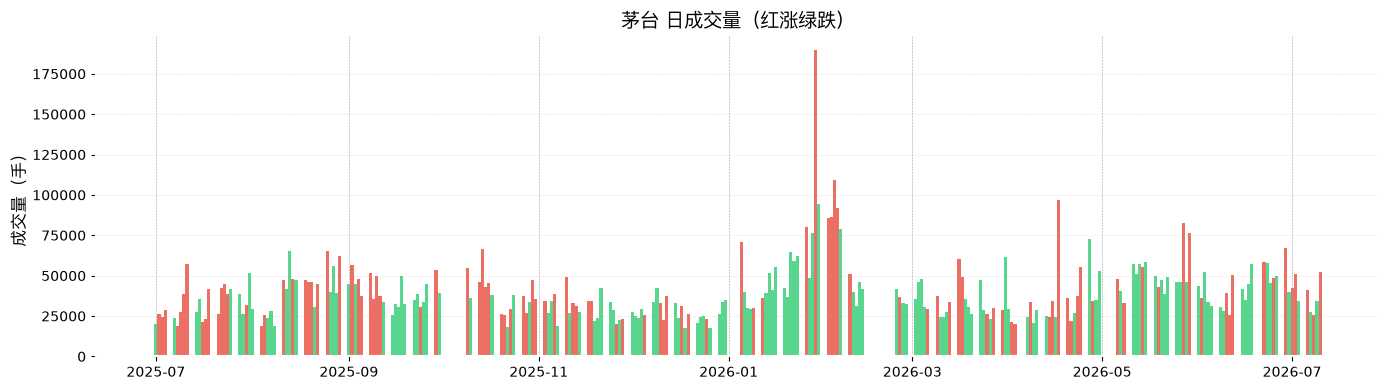

In [19]:
fig, ax = plt.subplots(figsize=(14, 4))

# 涨天红色，跌天绿色
colors = ['#e74c3c' if c >= o else '#2ecc71'
          for c, o in zip(df['收盘'], df['开盘'])]

ax.bar(df.index, df['成交量'], color=colors, width=1, alpha=0.8)
ax.set_title('茅台 日成交量（红涨绿跌）', fontproperties=zh_title)
ax.set_ylabel('成交量（手）', fontproperties=zh)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/Day11_成交量.png', dpi=150)
plt.show()

**量价配合口诀：**
- 价涨量增 → 健康上涨，买方充足 ✅
- 价涨量缩 → 量跟不上，动能不足 ⚠️
- 价跌量增 → 恐慌抛售，有人在砸 🔴
- 价跌量缩 → 卖盘衰竭，可能见底 👀

## 5. 日收益率分布直方图

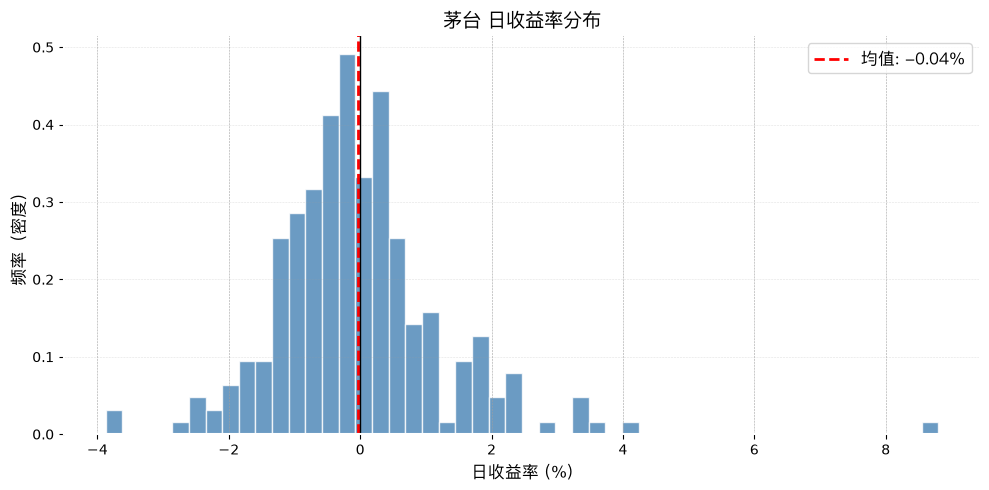

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

returns = df['日收益率'].dropna() * 100  # 转成百分比

ax.hist(returns, bins=50, color='steelblue', edgecolor='white', alpha=0.8, density=True)
ax.axvline(x=returns.mean(), color='red', linestyle='--', linewidth=2,
           label=f'均值: {returns.mean():.2f}%')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)

ax.set_title('茅台 日收益率分布', fontproperties=zh_title)
ax.set_xlabel('日收益率 (%)', fontproperties=zh)
ax.set_ylabel('频率（密度）', fontproperties=zh)
ax.legend(prop=zh)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/Day11_收益率分布.png', dpi=150)
plt.show()

**怎么看直方图：**
- 柱子最高的地方 = 最常见的日涨跌幅度
- 红色虚线(均值)在0左边 → 整体偏跌
- 两边尾巴又长又肥 → 极端行情多，风险大

## 6. 🔥 五股对比仪表面板

In [21]:
# 从CSV读取五只股票
import os

stocks = ['茅台', '比亚迪', '恒瑞医药', '海康威视', '招商银行']

all_close = {}
for name in stocks:
    df_s = pd.read_csv(f'../data/{name}.csv')
    df_s['日期'] = pd.to_datetime(df_s['日期'])
    df_s.set_index('日期', inplace=True)
    all_close[name] = df_s['收盘']

df_all = pd.DataFrame(all_close)
returns_all = df_all.pct_change().dropna()
print(f'五股数据 {df_all.shape[0]}天 x {df_all.shape[1]}只')

五股数据 250天 x 5只


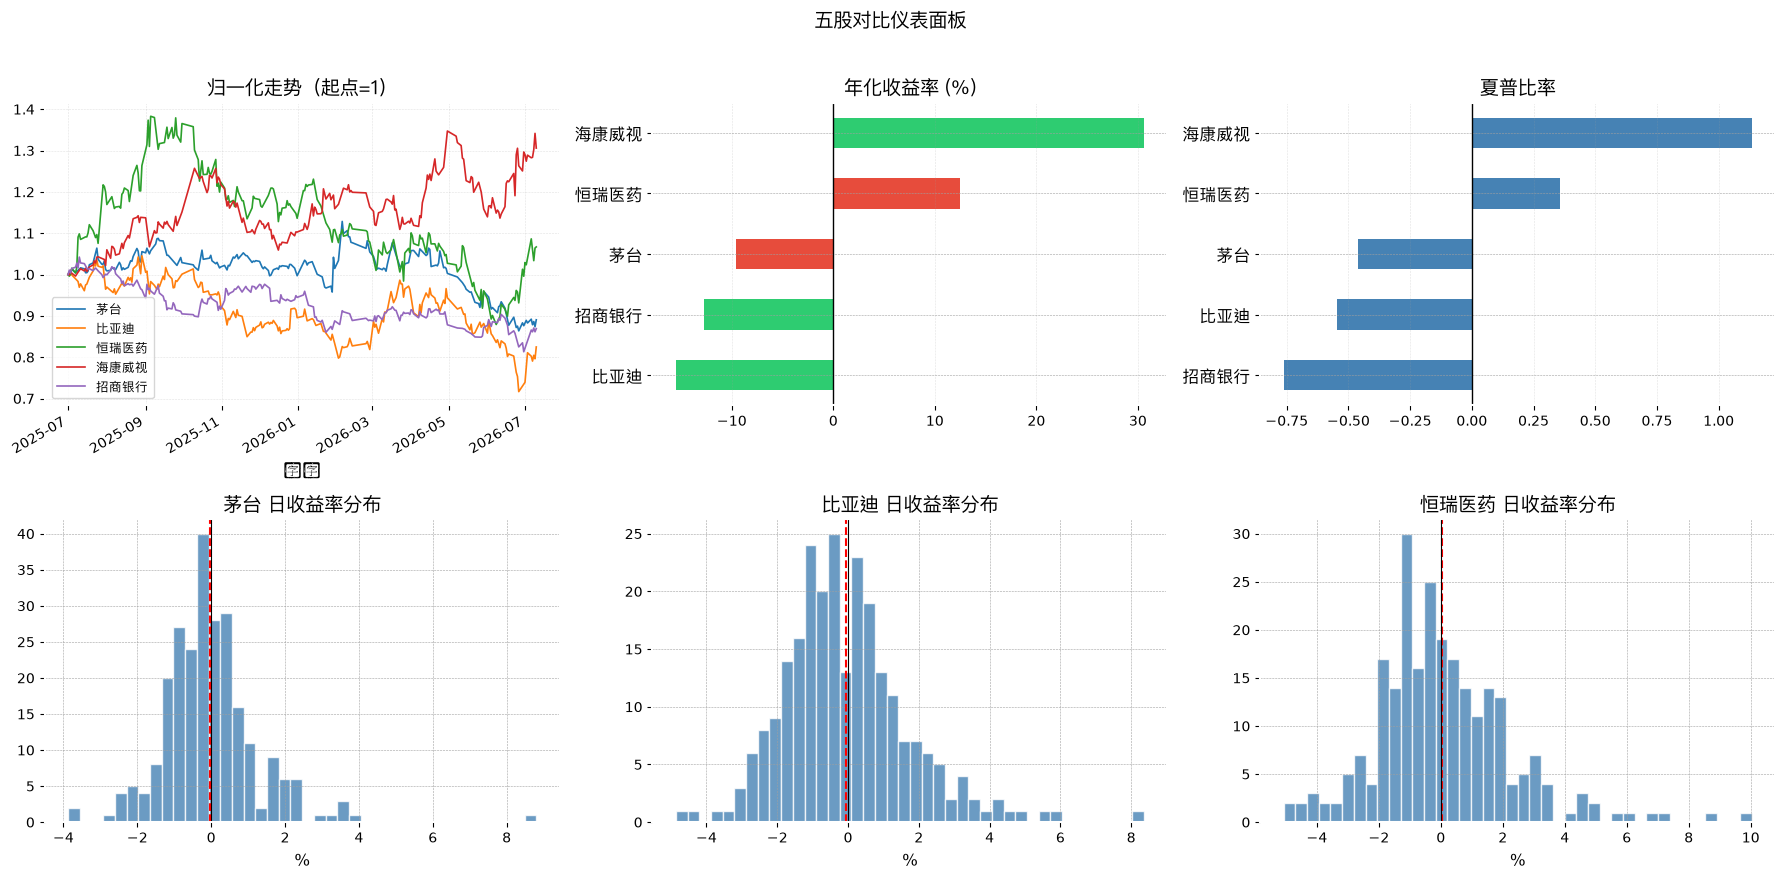

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# 图1: 归一化走势
df_norm = df_all / df_all.iloc[0]
df_norm.plot(ax=axes[0, 0], linewidth=1.2)
axes[0, 0].set_title('归一化走势（起点=1）', fontproperties=zh_title)
axes[0, 0].grid(True, alpha=0.3)
# pandas plot 的 legend 需要手动改字体
leg = axes[0, 0].get_legend()
if leg:
    for txt in leg.get_texts():
        txt.set_fontproperties(zh_small)

# 图2: 年化收益柱状图
annual_ret = returns_all.mean() * 252 * 100
colors_bar = ['#e74c3c' if x > 0 else '#2ecc71' for x in annual_ret]
annual_ret.sort_values().plot(kind='barh', ax=axes[0, 1], color=colors_bar)
axes[0, 1].set_title('年化收益率 (%)', fontproperties=zh_title)
axes[0, 1].axvline(x=0, color='black', linewidth=1)
axes[0, 1].grid(True, alpha=0.3, axis='x')
# 修改 y 轴标签字体（股票名）
for label in axes[0, 1].get_yticklabels():
    label.set_fontproperties(zh)

# 图3: 夏普比率
sharpe = (returns_all.mean() / returns_all.std()) * (252 ** 0.5)
sharpe.sort_values().plot(kind='barh', ax=axes[0, 2], color='steelblue')
axes[0, 2].set_title('夏普比率', fontproperties=zh_title)
axes[0, 2].axvline(x=0, color='black', linewidth=1)
axes[0, 2].grid(True, alpha=0.3, axis='x')
for label in axes[0, 2].get_yticklabels():
    label.set_fontproperties(zh)

# 图4-6: 前三只的收益率分布
stock_names = stocks[:3]
for i, name in enumerate(stock_names):
    ret = returns_all[name].dropna() * 100
    axes[1, i].hist(ret, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[1, i].axvline(x=ret.mean(), color='red', linestyle='--', linewidth=1.5)
    axes[1, i].axvline(x=0, color='black', linewidth=0.8)
    axes[1, i].set_title(f'{name} 日收益率分布', fontproperties=zh_title)
    axes[1, i].set_xlabel('%', fontproperties=zh)

# suptitle
fig.suptitle('五股对比仪表面板', fontproperties=zh_title, y=0.97)
fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('../outputs/Day11_五股面板.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 今日小结

| 图表 | 工具 | 看什么 |
|------|------|--------|
| K线图 | `mpf.plot(type='candle')` | 每天多空战况 |
| 均线叠加 | `plt.plot()` | 趋势方向 |
| 成交量 | `plt.bar()` | 量价配合 |
| 收益率直方图 | `plt.hist()` | 风险分布 |

**matplotlib画图三步：**
1. `fig, ax = plt.subplots()` — 创建画布
2. `ax.plot() / bar() / hist()` — 画图
3. `ax.set_title() / legend() / grid()` — 装修

**mplfinance = matplotlib的金融包装，K线一行搞定。**

### 关于数据获取
今天碰到的 `ConnectionError` 很正常——免费API都有限流。
**工程上的做法：数据拉一次，存CSV，后续直接读。** 你 data/ 目录下的CSV就是缓存。